In [51]:
!pip install transformers
!pip install vaderSentiment
!pip install textblob
!pip install spacy
!pip install afinn



## Imports


In [52]:
import re
from afinn import Afinn
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
import spacy
from textblob import TextBlob
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## Load Data and Preprocessing

In [53]:
data = pd.read_csv("/content/IMDB Dataset.csv").sample(500, random_state=42).copy()
data.head()

,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 33553 to 27658
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     500 non-null    object
 1   sentiment  500 non-null    object
dtypes: object(2)
memory usage: 11.7+ KB


In [55]:
data['review'] = data['review'].str.lower()

In [56]:


def clean_text(text):
  text = re.sub(r"<.*?>", " ", text)
  text = re.sub(r"([^\w\s])", "", text)
  return text.lower().strip()

data["review_clean"] = data["review"].apply(clean_text)
data["sentiment_ground_truth"] = data["sentiment"].str.capitalize()

In [57]:
data.head()

,review,sentiment,review_clean,sentiment_ground_truth
33553,i really liked this summerslam due to the look...,positive,i really liked this summerslam due to the look...,Positive
9427,not many television shows appeal to quite as m...,positive,not many television shows appeal to quite as m...,Positive
199,the film quickly gets to a major chase scene w...,negative,the film quickly gets to a major chase scene w...,Negative
12447,jane austen would definitely approve of this o...,positive,jane austen would definitely approve of this o...,Positive
39489,expectations were somewhat high for me when i ...,negative,expectations were somewhat high for me when i ...,Negative


## Split Data

In [58]:
train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data["sentiment_ground_truth"],
)

test_data = test_data.copy()

print(f"Total dataset: {len(data)} rows")
print(f"Training set:  {len(train_data)} rows")
print(f"Testing set:   {len(test_data)} rows (Target evaluation partition)\n")

Total dataset: 500 rows
Training set:  400 rows
Testing set:   100 rows (Target evaluation partition)



## POS Tagging & NER

In [59]:
nlp = spacy.load("en_core_web_sm")
sample_doc = nlp(test_data["review_clean"].iloc[0])

# POS Tagging Sample
pos_df = pd.DataFrame(
    [{"token": token.text, "pos_tag": token.pos_} for token in sample_doc]
)
print("--- POS Tagging Sample ---")
print(pos_df.head(), "\n")

# NER Sample
ner_df = pd.DataFrame(
    [{"entity": ent.text, "label": ent.label_} for ent in sample_doc.ents]
)
print("--- NER Sample ---")
print(
    ner_df.head()
    if not ner_df.empty
    else "No entities found in the selected sample.\n"
)

--- POS Tagging Sample ---
      token pos_tag
0     being     AUX
1  american     ADJ
2         i    PRON
3      have     AUX
4       not    PART 

--- NER Sample ---
     entity label
0  american  NORP
1  american  NORP


## Sentiment Analysis: VADER & TextBlob

In [60]:
# VADER
vader_analyzer = SentimentIntensityAnalyzer()
test_data["vader_compound"] = test_data["review_clean"].apply(
    lambda x: vader_analyzer.polarity_scores(x)["compound"]
)
test_data["vader_sentiment"] = pd.cut(
    test_data["vader_compound"],
    bins=[-1.01, 0.0, 1.01],
    labels=["Negative", "Positive"],
    include_lowest=True,
)
print("--- VADER Sample ---")
print(test_data["vader_sentiment"].value_counts())

# TextBlob
test_data["textblob_polarity"] = test_data["review_clean"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)
test_data["textblob_sentiment"] = pd.cut(
    test_data["textblob_polarity"],
    bins=[-1.01, 0.0, 1.01],
    labels=["Negative", "Positive"],
    include_lowest=True,
)
print("\n--- TextBlob Sample ---")
print(test_data["textblob_sentiment"].value_counts())

--- VADER Sample ---
vader_sentiment
Positive    67
Negative    33
Name: count, dtype: int64

--- TextBlob Sample ---
textblob_sentiment
Positive    76
Negative    24
Name: count, dtype: int64


## Sentiment Analysis: Afinn

In [61]:
afinn = Afinn()
test_data["afinn_score"] = test_data["review_clean"].apply(
    lambda x: afinn.score(x)
)
test_data["afinn_sentiment"] = pd.cut(
    test_data["afinn_score"],
    bins=[-float("inf"), 0.0, float("inf")],
    labels=["Negative", "Positive"],
    include_lowest=True,
)
print("--- Afinn Sample ---")
print(test_data["afinn_sentiment"].value_counts())

--- Afinn Sample ---
afinn_sentiment
Positive    66
Negative    34
Name: count, dtype: int64


## Pre-trained Transformers Default

In [62]:
default_pipeline = pipeline(
    "sentiment-analysis", truncation=True, max_length=512
)
test_data["transformer_default"] = test_data["review_clean"].apply(
    lambda x: default_pipeline(x)[0]["label"].capitalize()
)
print("\n--- Transformer Default Sample ---")
print(test_data["transformer_default"].value_counts())

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- Transformer Default Sample ---
transformer_default
Negative    62
Positive    38
Name: count, dtype: int64


## Pre-trained Transformers Specific Model

In [63]:
# Additional Transformer Model 1: RoBERTa for Movie/Review Sentiment
# (Model: siebert/sentiment-roberta-large-english)
roberta_pipeline = pipeline(
    "sentiment-analysis",
    model="siebert/sentiment-roberta-large-english",
    truncation=True,
    max_length=512,
)
test_data["transformer_roberta"] = test_data["review_clean"].apply(
    lambda x: roberta_pipeline(x)[0]["label"].capitalize()
)
print("\n--- Transformer RoBERTa Sample ---")
print(test_data["transformer_roberta"].value_counts())

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


--- Transformer RoBERTa Sample ---
transformer_roberta
Negative    53
Positive    47
Name: count, dtype: int64


In [64]:
# Additional Transformer Model 2: ALBERT for Binary Sentiment
# (Model: textattack/albert-base-v2-SST-2)

albert_pipeline = pipeline(
    "sentiment-analysis",
    model="textattack/albert-base-v2-SST-2",
    truncation=True,
    max_length=512,
)


def parse_albert_label(text):
  label = albert_pipeline(text)[0]["label"]
  return "Positive" if label in ["LABEL_1", "POSITIVE"] else "Negative"


test_data["transformer_albert"] = test_data["review_clean"].apply(
    parse_albert_label
)
print("\n--- Transformer ALBERT Sample ---")
print(test_data["transformer_albert"].value_counts())

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]


--- Transformer ALBERT Sample ---
transformer_albert
Negative    59
Positive    41
Name: count, dtype: int64


## Visualizing Predictions across All Models (Bar Plots)

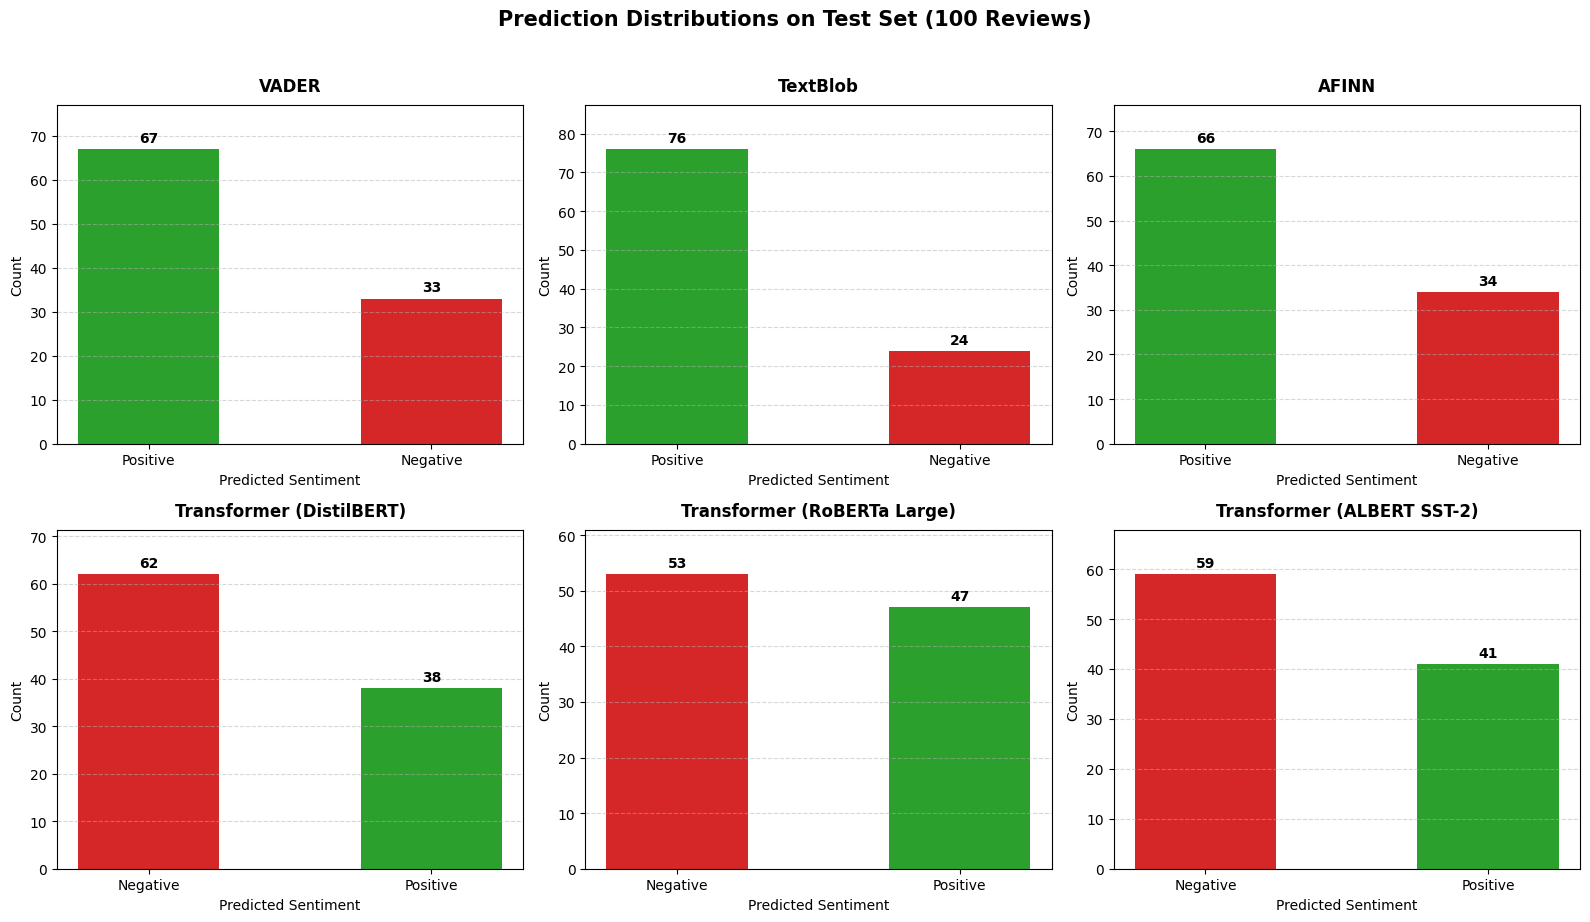

In [65]:
models_to_plot = [
    ("vader_sentiment", "VADER"),
    ("textblob_sentiment", "TextBlob"),
    ("afinn_sentiment", "AFINN"),
    ("transformer_default", "Transformer (DistilBERT)"),
    ("transformer_roberta", "Transformer (RoBERTa Large)"),
    ("transformer_albert", "Transformer (ALBERT SST-2)"),
]

palette = {"Positive": "#2ca02c", "Negative": "#d62728"}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (col, title) in zip(axes.flatten(), models_to_plot):
  counts = test_data[col].value_counts()
  colors = [palette.get(str(label), "#7f7f7f") for label in counts.index]
  bars = ax.bar(
      counts.index.astype(str), counts.values, color=colors, width=0.5
  )

  for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

  ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
  ax.set_xlabel("Predicted Sentiment")
  ax.set_ylabel("Count")
  ax.set_ylim(0, max(counts.max() * 1.15, 10))
  ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle(
    f"Prediction Distributions on Test Set ({len(test_data)} Reviews)",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()



## Test Set Evaluation & Accuracy Benchmarking



In [66]:
y_true = test_data["sentiment_ground_truth"].values

benchmark_results = []
for col, model_name in models_to_plot:
  y_pred = test_data[col].astype(str).values
  acc = accuracy_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred, pos_label="Positive")
  benchmark_results.append({
      "Model": model_name,
      "Test Accuracy (%)": round(acc * 100, 2),
      "Test F1-Score": round(f1, 4),
  })

benchmark_df = pd.DataFrame(benchmark_results).sort_values(
    by="Test Accuracy (%)", ascending=False
)
print("\n=== Model Performance on Test Set ===")
print(benchmark_df.to_string(index=False))

# Classification Report for the Best Transformer
print("\n=== Detailed Report: RoBERTa Large ===")
print(
    classification_report(y_true, test_data["transformer_roberta"].astype(str))
)



=== Model Performance on Test Set ===
                      Model  Test Accuracy (%)  Test F1-Score
Transformer (RoBERTa Large)               94.0         0.9375
 Transformer (ALBERT SST-2)               88.0         0.8667
   Transformer (DistilBERT)               81.0         0.7816
                      AFINN               73.0         0.7652
                      VADER               68.0         0.7241
                   TextBlob               63.0         0.7040

=== Detailed Report: RoBERTa Large ===
              precision    recall  f1-score   support

    Negative       0.92      0.96      0.94        51
    Positive       0.96      0.92      0.94        49

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



## Final Accuracy Comparison Plot


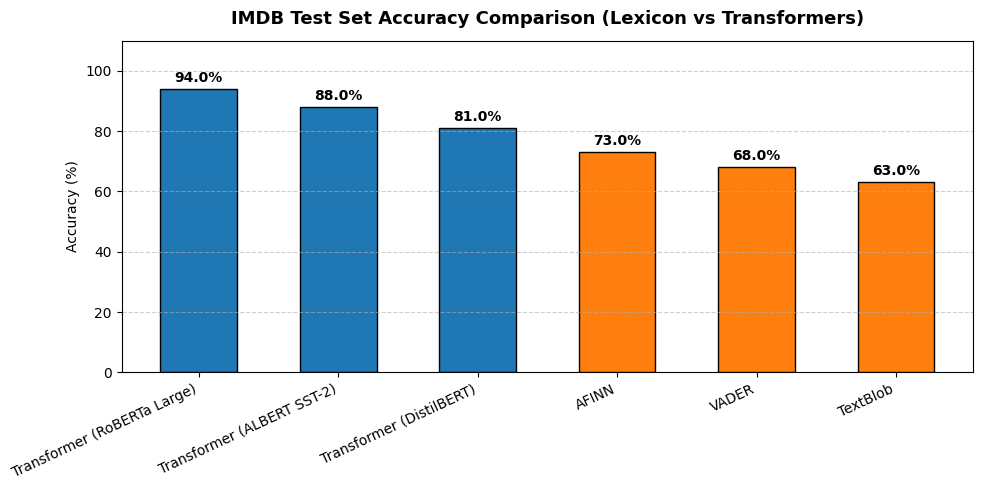

In [67]:
plt.figure(figsize=(10, 5))
colors = [
    "#1f77b4" if "Transformer" in name else "#ff7f0e"
    for name in benchmark_df["Model"]
]
bars = plt.bar(
    benchmark_df["Model"],
    benchmark_df["Test Accuracy (%)"],
    color=colors,
    width=0.55,
    edgecolor="black",
)

for bar in bars:
  h = bar.get_height()
  plt.annotate(
      f"{h}%",
      xy=(bar.get_x() + bar.get_width() / 2, h),
      xytext=(0, 3),
      textcoords="offset points",
      ha="center",
      va="bottom",
      fontweight="bold",
  )

plt.title(
    "IMDB Test Set Accuracy Comparison (Lexicon vs Transformers)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()